# Temple and Religious Gathering Crowd Stampede Pressure Index Prediction

### Machine Learning Project

**Student:** Mayur Pawar  
**Course:** M.Sc. Computer Science  
**College:** MIT Arts, Commerce and Science College  
**Academic Year:** 2026–2027

---

### Project Objective

The objective of this project is to develop a machine learning system
that estimates a numerical Crowd Pressure Index and classifies crowd
conditions into Safe, Moderate, or Critical levels.

 ### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [3]:
df = pd.read_excel("Temple_Crowd_Pressure_Dataset_20000.xlsx")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (12009, 15)


### Display Dataset

In [4]:
display(df.head())

,Date,Time,Location,Crowd Count,Inflow Rate,Outflow Rate,Crowd Density,Weather,Temperature,Event Day,Holiday,Corridor Width,Corridor Capacity,Flow Speed,Bottleneck Indicator
0,2026-09-27,21:09:00,"Bhimashankar Temple, Maharashtra",6631,431.0,322.0,7.02,Humid,27.9,No,No,5.9,590.0,1.52,No
1,2026-10-05,17:52:00,"Meenakshi Amman Temple, Madurai",3454,541.0,459.0,6.54,Humid,27.7,No,Yes,2.2,327.0,1.98,No
2,2025-05-18,00:44:00,"Vaishno Devi Temple, Katra",9975,492.0,307.0,6.13,Sunny,33.6,No,No,4.1,843.0,1.02,Yes
3,2026-02-04,01:51:00,"Shri Siddhivinayak Temple, Mumbai",1117,63.0,140.0,6.23,Rainy,20.7,No,No,9.0,661.0,0.37,No
4,2026-09-13,15:49:00,"Meenakshi Amman Temple, Madurai",11752,501.0,304.0,1.18,Hot,18.4,No,No,8.6,467.0,2.50,No


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Date', 'Time', 'Location', 'Crowd Count', 'Inflow Rate', 'Outflow Rate', 'Crowd Density', 'Weather', 'Temperature', 'Event Day', 'Holiday', 'Corridor Width', 'Corridor Capacity', 'Flow Speed', 'Bottleneck Indicator']


### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12009 entries, 0 to 12008
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  12009 non-null  datetime64[ns]
 1   Time                  12009 non-null  object        
 2   Location              12009 non-null  object        
 3   Crowd Count           12009 non-null  int64         
 4   Inflow Rate           12006 non-null  float64       
 5   Outflow Rate          12006 non-null  float64       
 6   Crowd Density         12006 non-null  float64       
 7   Weather               12006 non-null  object        
 8   Temperature           12005 non-null  float64       
 9   Event Day             12009 non-null  object        
 10  Holiday               12009 non-null  object        
 11  Corridor Width        12009 non-null  float64       
 12  Corridor Capacity     12006 non-null  float64       
 13  Flow Speed      

In [7]:
display(df.describe())

,Date,Crowd Count,Inflow Rate,Outflow Rate,Crowd Density,Temperature,Corridor Width,Corridor Capacity,Flow Speed
count,12009,12009.000000,12006.000000,12006.000000,12006.000000,12005.000000,12009.000000,12006.000000,12006.000000
mean,2025-06-30 17:02:28.388708608,7501.882338,304.659753,253.128686,7.732964,29.842257,6.996686,1649.173497,1.393233
min,2024-01-01 00:00:00,100.000000,10.000000,5.000000,0.500000,18.000000,2.000000,300.000000,0.300000
25%,2024-10-01 00:00:00,3729.000000,157.000000,130.000000,4.100000,23.800000,4.500000,974.000000,0.820000
50%,2025-07-02 00:00:00,7489.000000,305.000000,254.000000,7.780000,29.700000,7.000000,1657.000000,1.390000
75%,2026-03-28 00:00:00,11250.000000,452.000000,376.000000,11.310000,35.900000,9.500000,2329.000000,1.950000
max,2026-12-31 00:00:00,15000.000000,600.000000,500.000000,15.000000,42.000000,12.000000,3000.000000,2.500000
std,NaN,4333.844251,170.173360,142.934519,4.176110,6.941284,2.899872,780.502086,0.642643


### Check Missing Values

In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date                    0
Time                    0
Location                0
Crowd Count             0
Inflow Rate             3
Outflow Rate            3
Crowd Density           3
Weather                 3
Temperature             4
Event Day               0
Holiday                 0
Corridor Width          0
Corridor Capacity       3
Flow Speed              3
Bottleneck Indicator    0
dtype: int64


### Check Duplicate Records

In [9]:
print("Duplicate Records:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicate Records: 0
Shape After Removing Duplicates: (12009, 15)


### Data Cleaning

In [10]:
numeric_columns = [
    "Crowd Count",
    "Inflow Rate",
    "Outflow Rate",
    "Crowd Density",
    "Temperature",
    "Corridor Width",
    "Corridor Capacity",
    "Flow Speed"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())
categorical_columns = [
    "Location",
    "Weather",
    "Event Day",
    "Holiday",
    "Bottleneck Indicator"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])   
print(df.isnull().sum())    

Date                    0
Time                    0
Location                0
Crowd Count             0
Inflow Rate             0
Outflow Rate            0
Crowd Density           0
Weather                 0
Temperature             0
Event Day               0
Holiday                 0
Corridor Width          0
Corridor Capacity       0
Flow Speed              0
Bottleneck Indicator    0
dtype: int64


### Convert Date and Time

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

df["Hour"] = pd.to_datetime(
    df["Time"].astype(str)
).dt.hour

In [13]:
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year


### Exploratory Data Analysis
## 1)Crowd Count

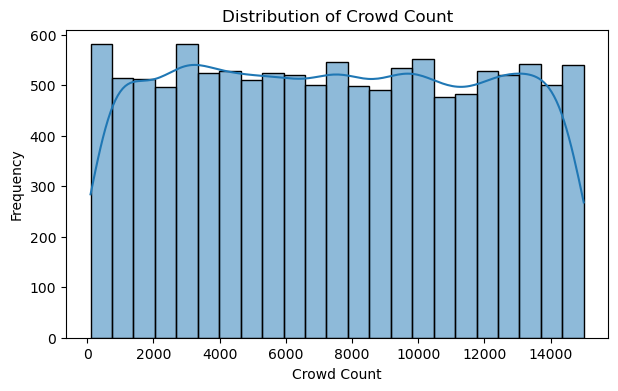

In [22]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["Crowd Count"],
    kde=True
)

plt.title("Distribution of Crowd Count")
plt.xlabel("Crowd Count")
plt.ylabel("Frequency")

plt.show()

## 2) Crowd Density

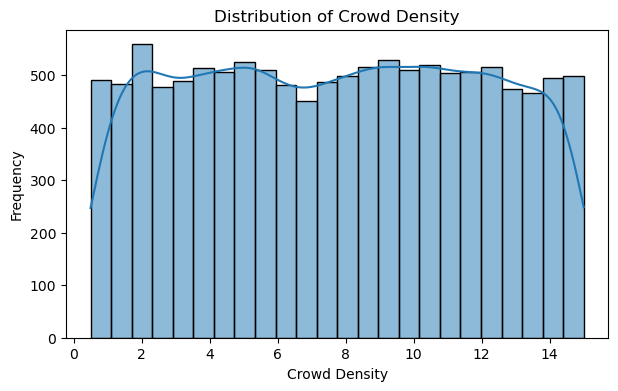

In [25]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["Crowd Density"],
    kde=True
)

plt.title("Distribution of Crowd Density")
plt.xlabel("Crowd Density")
plt.ylabel("Frequency")

plt.show()

### 3) Inflow and Outflow

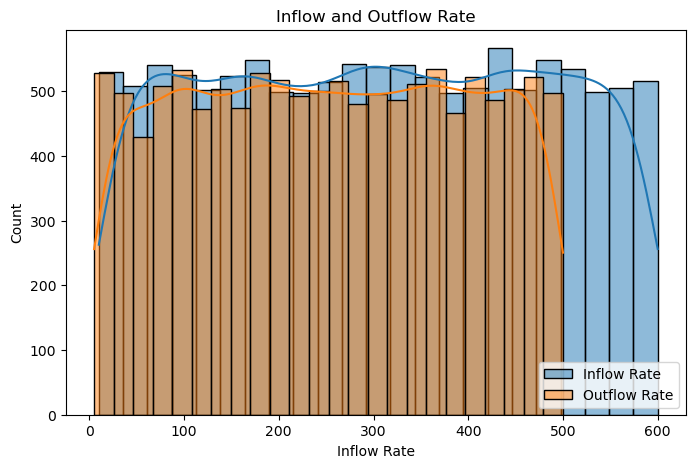

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Inflow Rate"],
    kde=True,
    label="Inflow Rate"
)

sns.histplot(
    df["Outflow Rate"],
    kde=True,
    label="Outflow Rate"
)

plt.title("Inflow and Outflow Rate")
plt.legend()

plt.show()

### Correlation Matrix

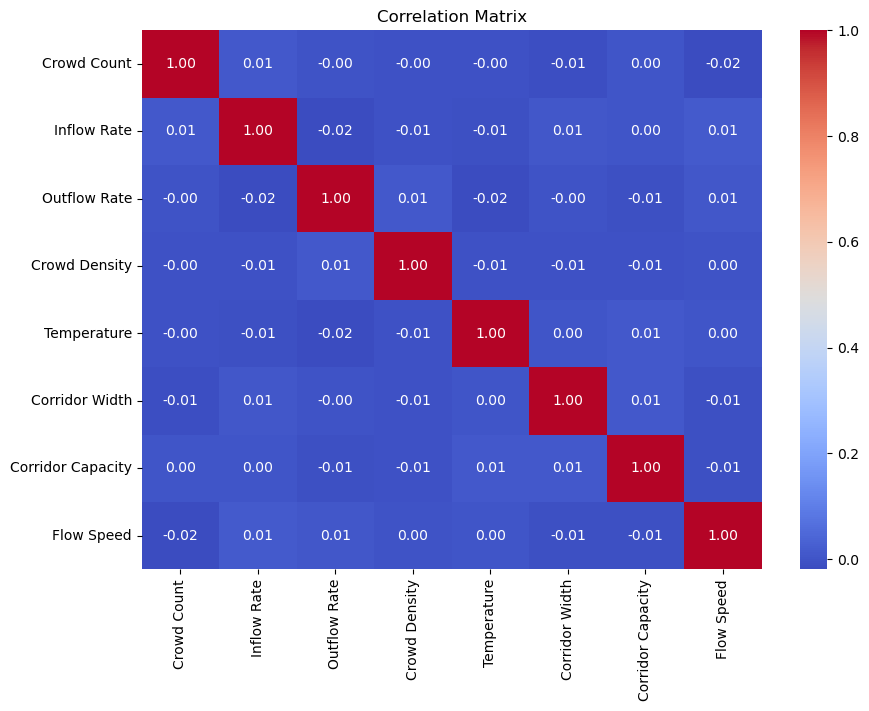

In [27]:
correlation_columns = [
    "Crowd Count",
    "Inflow Rate",
    "Outflow Rate",
    "Crowd Density",
    "Temperature",
    "Corridor Width",
    "Corridor Capacity",
    "Flow Speed"
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Create Crowd Pressure Index


## Density Score

In [28]:
df["Density Score"] = (
    df["Crowd Density"] /
    df["Crowd Density"].max()
) * 100

### Inflow Score

In [29]:
df["Inflow Score"] = (
    df["Inflow Rate"] /
    df["Inflow Rate"].max()
) * 100

### Capacity Score

In [30]:
df["Capacity Score"] = (
    df["Crowd Count"] /
    df["Corridor Capacity"]
) * 100

In [31]:
df["Capacity Score"] = df[
    "Capacity Score"
].clip(0, 100)

### Speed Reduction Score

In [32]:
df["Speed Score"] = (
    1 -
    df["Flow Speed"] /
    df["Flow Speed"].max()
) * 100

In [33]:
df["Speed Score"] = df[
    "Speed Score"
].clip(0, 100)

### Calculate Crowd Pressure Index

In [36]:
df["Crowd Pressure Index"] = (
    0.30 * df["Density Score"] +
    0.25 * df["Inflow Score"] +
    0.30 * df["Capacity Score"] +
    0.15 * df["Speed Score"]
)
df["Crowd Pressure Index"] = df[
    "Crowd Pressure Index"
].clip(0, 100)
display(
    df[
        [
            "Crowd Count",
            "Inflow Rate",
            "Outflow Rate",
            "Crowd Density",
            "Corridor Capacity",
            "Flow Speed",
            "Crowd Pressure Index"
        ]
    ].head(10)
)

,Crowd Count,Inflow Rate,Outflow Rate,Crowd Density,Corridor Capacity,Flow Speed,Crowd Pressure Index
0,6631,431.0,322.0,7.02,590.0,1.52,67.878333
1,3454,541.0,459.0,6.54,327.0,1.98,68.741667
2,9975,492.0,307.0,6.13,843.0,1.02,71.640000
3,1117,63.0,140.0,6.23,661.0,0.37,57.865000
4,11752,501.0,304.0,1.18,467.0,2.50,53.235000
5,11274,298.0,130.0,3.11,2436.0,2.28,49.956667
6,3698,263.0,393.0,1.06,1107.0,1.57,48.658333
7,5363,246.0,212.0,1.34,2630.0,1.98,46.050000
8,10581,261.0,98.0,6.73,957.0,0.70,65.135000
9,10339,574.0,319.0,4.24,302.0,0.40,74.996667


### Create Risk Level

In [37]:
def get_risk_level(pressure):

    if pressure <= 30:
        return "Safe"

    elif pressure <= 60:
        return "Moderate"

    else:
        return "Critical"

df["Risk Level"] = df[
    "Crowd Pressure Index"
].apply(get_risk_level)
print(df["Risk Level"].value_counts())

Risk Level
Critical    7312
Moderate    4585
Safe         112
Name: count, dtype: int64


### Risk Level Graph

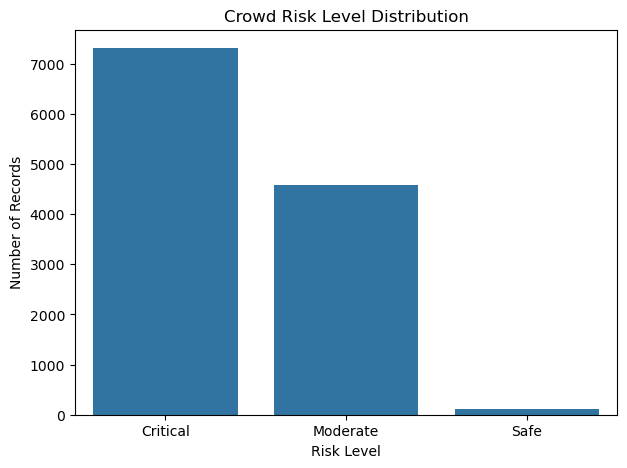

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Risk Level"
)

plt.title("Crowd Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

### Pressure Index Graph

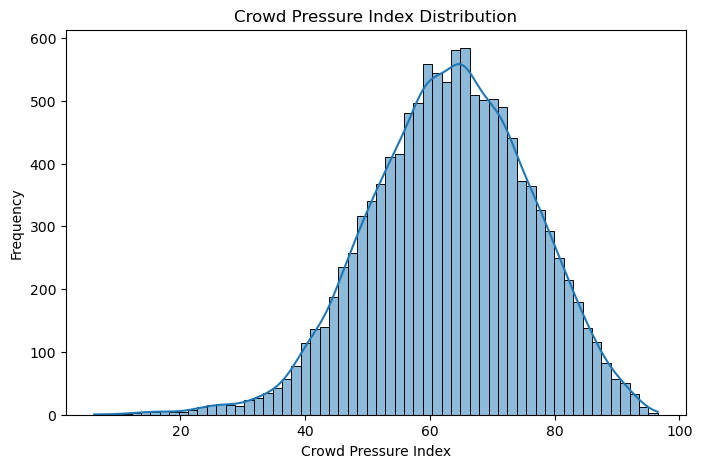

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Crowd Pressure Index"],
    kde=True
)

plt.title("Crowd Pressure Index Distribution")
plt.xlabel("Crowd Pressure Index")
plt.ylabel("Frequency")

plt.show()

### Prepare Features for Regression

In [43]:
features = [
    "Crowd Count",
    "Inflow Rate",
    "Outflow Rate",
    "Crowd Density",
    "Temperature",
    "Corridor Width",
    "Corridor Capacity",
    "Flow Speed"
]
X = df[features]

y = df["Crowd Pressure Index"]

### Train-Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 9607
Testing Records: 2402


### Feature Scaling

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Regression Model 1 — Linear Regression

In [46]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_prediction = linear_model.predict(
    X_test_scaled
)
linear_mae = mean_absolute_error(
    y_test,
    linear_prediction
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_prediction
    )
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear Regression")
print("-------------------------")
print("MAE  :", round(linear_mae, 3))
print("RMSE :", round(linear_rmse, 3))
print("R2   :", round(linear_r2, 3))

Linear Regression
-------------------------
MAE  : 2.992
RMSE : 4.688
R2   : 0.867


### Regression Model 2 — Random Forest

In [47]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_regressor.fit(
    X_train,
    y_train
)

rf_prediction = rf_regressor.predict(
    X_test
)
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

print("Random Forest Regression")
print("-------------------------")
print("MAE  :", round(rf_mae, 3))
print("RMSE :", round(rf_rmse, 3))
print("R2   :", round(rf_r2, 3))

Random Forest Regression
-------------------------
MAE  : 0.988
RMSE : 2.053
R2   : 0.974


### Compare Regression Models

In [48]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

display(regression_results)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.991817,4.688091,0.866567
1,Random Forest Regression,0.987722,2.053319,0.974403


### Actual vs Predicted Graph

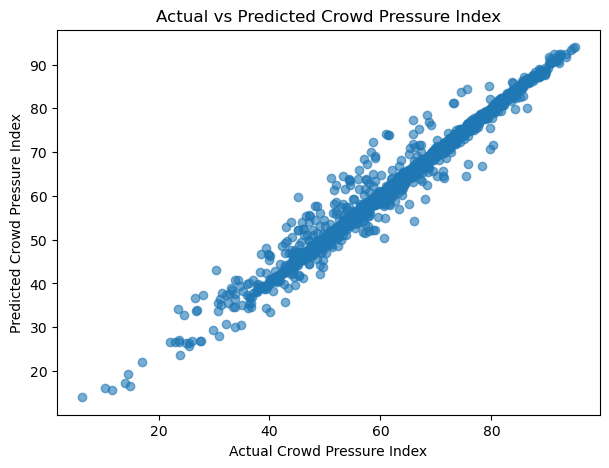

In [49]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    rf_prediction,
    alpha=0.6
)

plt.xlabel("Actual Crowd Pressure Index")
plt.ylabel("Predicted Crowd Pressure Index")

plt.title(
    "Actual vs Predicted Crowd Pressure Index"
)

plt.show()

### Feature Importance

,Feature,Importance
3,Crowd Density,0.424933
1,Inflow Rate,0.312693
0,Crowd Count,0.145472
7,Flow Speed,0.090494
6,Corridor Capacity,0.020832
4,Temperature,0.001989
2,Outflow Rate,0.001859
5,Corridor Width,0.001728


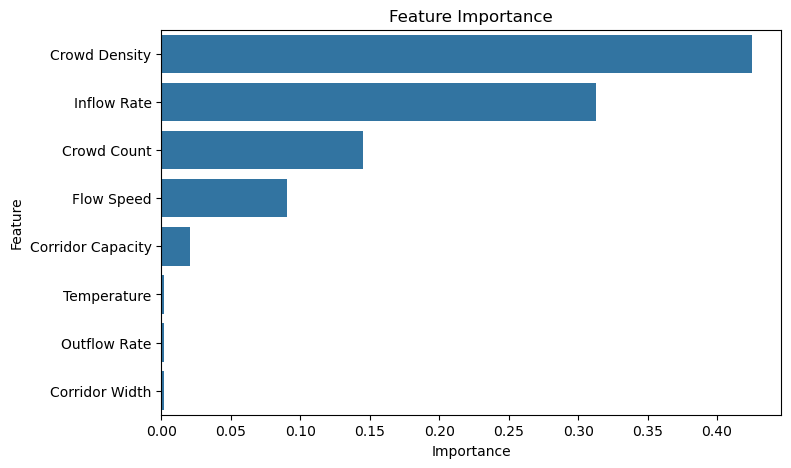

In [50]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_regressor.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

### Classification

In [51]:
X = df[features]

y = df["Risk Level"]

### Classification Train-Test Split

In [52]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Logistic Regression

In [55]:
classification_scaler = StandardScaler()

X_train_c_scaled = classification_scaler.fit_transform(
    X_train_c
)

X_test_c_scaled = classification_scaler.transform(
    X_test_c
)
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_c_scaled,
    y_train_c
)

logistic_prediction = logistic_model.predict(
    X_test_c_scaled
)
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_c_scaled,
    y_train_c
)

logistic_prediction = logistic_model.predict(
    X_test_c_scaled
)
logistic_accuracy = accuracy_score(
    y_test_c,
    logistic_prediction
)

logistic_precision = precision_score(
    y_test_c,
    logistic_prediction,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test_c,
    logistic_prediction,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_c,
    logistic_prediction,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("-------------------------")
print("Accuracy :", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall   :", round(logistic_recall, 3))
print("F1 Score :", round(logistic_f1, 3))

Logistic Regression
-------------------------
Accuracy : 0.921
Precision: 0.922
Recall   : 0.921
F1 Score : 0.92


### Random Forest Classification

In [56]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_classifier.fit(
    X_train_c,
    y_train_c
)

rf_class_prediction = rf_classifier.predict(
    X_test_c
)
rf_accuracy = accuracy_score(
    y_test_c,
    rf_class_prediction
)

rf_precision = precision_score(
    y_test_c,
    rf_class_prediction,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test_c,
    rf_class_prediction,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test_c,
    rf_class_prediction,
    average="weighted",
    zero_division=0
)

print("Random Forest Classification")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1 Score :", round(rf_f1, 3))

Random Forest Classification
-------------------------
Accuracy : 0.964
Precision: 0.964
Recall   : 0.964
F1 Score : 0.963


### Classification Model Comparison

In [57]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest Classification"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

display(classification_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.921316,0.921547,0.921316,0.920466
1,Random Forest Classification,0.964197,0.964377,0.964197,0.963034


### Classification Report

In [58]:
print(
    classification_report(
        y_test_c,
        rf_class_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Critical       0.96      0.99      0.98      1463
    Moderate       0.96      0.94      0.95       917
        Safe       1.00      0.41      0.58        22

    accuracy                           0.96      2402
   macro avg       0.98      0.78      0.84      2402
weighted avg       0.96      0.96      0.96      2402



### Confusion Matrix

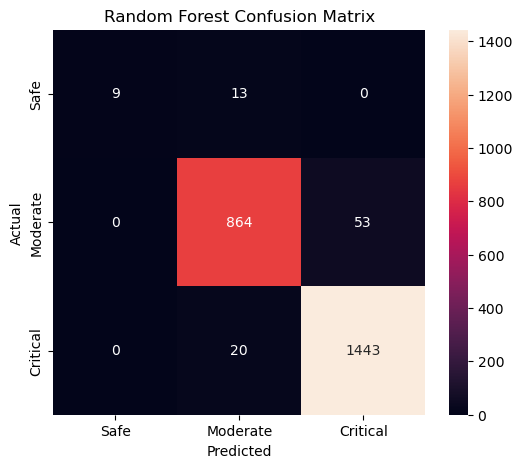

In [59]:
labels = [
    "Safe",
    "Moderate",
    "Critical"
]

cm = confusion_matrix(
    y_test_c,
    rf_class_prediction,
    labels=labels
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

### Test a New Crowd Situation

In [60]:
new_crowd = pd.DataFrame({
    "Crowd Count": [9000],
    "Inflow Rate": [700],
    "Outflow Rate": [400],
    "Crowd Density": [85],
    "Temperature": [30],
    "Corridor Width": [5],
    "Corridor Capacity": [10000],
    "Flow Speed": [0.8]
})
pressure_prediction = rf_regressor.predict(
    new_crowd
)[0]

pressure_prediction = np.clip(
    pressure_prediction,
    0,
    100
)

print(
    "Predicted Crowd Pressure Index:",
    round(pressure_prediction, 2)
)

Predicted Crowd Pressure Index: 93.55


### Predict Risk Level

In [61]:
risk_prediction = rf_classifier.predict(
    new_crowd
)[0]

print(
    "Predicted Risk Level:",
    risk_prediction
)
risk_prediction = rf_classifier.predict(
    new_crowd
)[0]

print(
    "Predicted Risk Level:",
    risk_prediction
)

Predicted Risk Level: Critical
Predicted Risk Level: Critical


### Save Final Dataset

In [62]:
df.to_excel(
    "Temple_Crowd_Pressure_Final.xlsx",
    index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.
